<a href="https://colab.research.google.com/github/xseeker0/neural-scratchpad/blob/main/practice_3_3_attention_and_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention mechanism

## Scale Dot-Product Attention

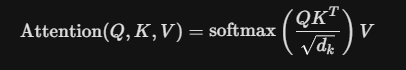

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import math
import copy

class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            # Mask out invalid positions with a very small value
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        output = torch.matmul(attn, V)

        return output

## Multi-Head Attention
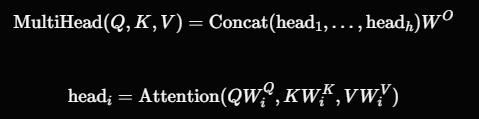

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads, dropout=0.1):
        super().__init__()
        assert d_model % heads == 0
        self.d_k = d_model // heads
        self.h = heads

        # 3 Linears for Q, K, V projections and 1 for Output concatenation
        self.linears = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(4)])
        self.dropout = nn.Dropout(dropout)
        self.attn_map = None # Store attention weights for visualization

    def forward(self, q, k, v, mask=None):
        nbatches = q.size(0)

        # 1. Linear projections and split into heads: (B, L, D) -> (B, H, L, D_k)
        q, k, v = [l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
                   for l, x in zip(self.linears, (q, k, v))]

        # 2. Scaled Dot-Product Attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        self.attn_map = F.softmax(scores, dim=-1)
        x = torch.matmul(self.dropout(self.attn_map), v)

        # 3. Concatenate heads: (B, H, L, D_k) -> (B, L, D)
        x = x.transpose(1, 2).contiguous().view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)

# Transformer

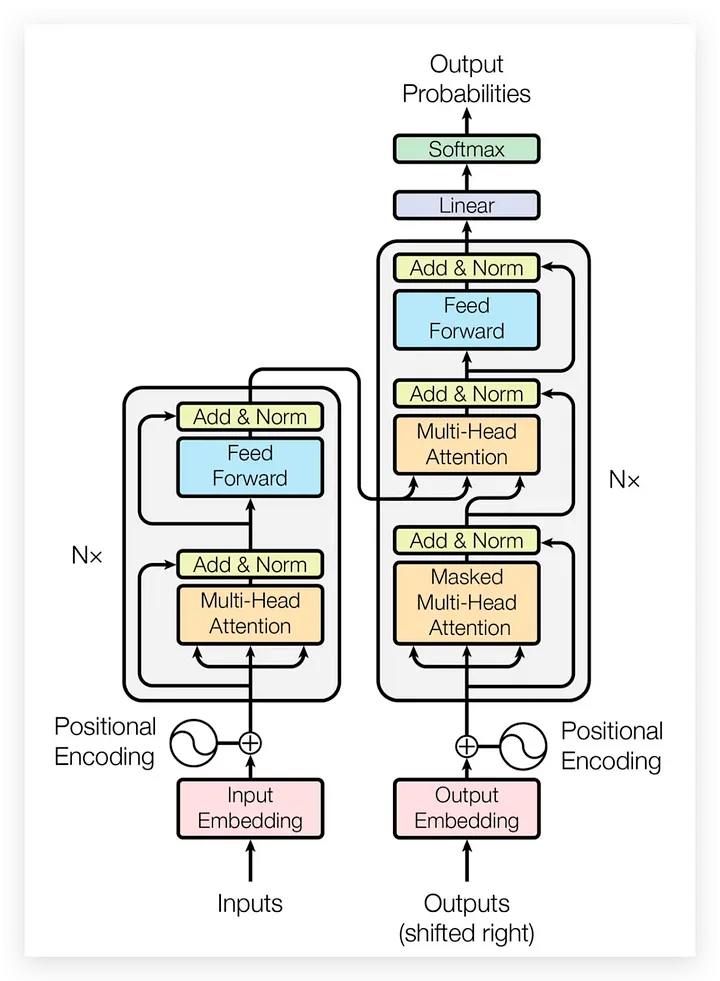

## Positional Encoding
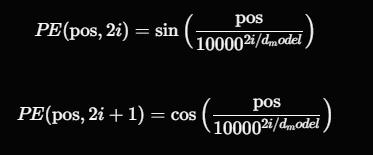

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Init
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # Numerical trick
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Apply sine to even indices and cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # register_buffer saves 'pe' in state_dict without calculating gradients
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [Batch, Seq_Len, D_Model]
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

## Layer norm
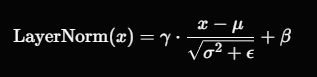

In [4]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        # Learnable parameters: gamma (weight) and beta (bias)
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        # x shape: [Batch, Seq_Len, D_Model]
        # Calculate mean and variance along the last dimension (D_Model)
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True, unbiased=False)

        # Standardize and rescale
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

## Skip connection
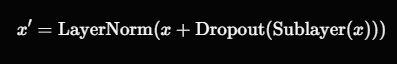

## Feed Forward

In [5]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        # Position-wise Feed-Forward Network
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

## Encoder

In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Post-Norm architecture: Norm(x + Dropout(Sublayer(x)))
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x

## Decoder

In [7]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        # Self-attention with causal masking
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        # Cross-attention connecting Encoder and Decoder
        x = self.norm2(x + self.dropout(self.cross_attn(x, memory, memory, src_mask)))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x

## Transformer and generator

In [8]:
class Generator(nn.Module):
    def __init__(self, d_model, vocab):
        super().__init__()
        # Project D_Model back to Vocab size
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, heads=8, layers=2, d_ff=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = PositionalEncoding(d_model, dropout)

        self.encoder = nn.ModuleList([EncoderLayer(d_model, heads, d_ff, dropout) for _ in range(layers)])
        self.decoder = nn.ModuleList([DecoderLayer(d_model, heads, d_ff, dropout) for _ in range(layers)])
        self.generator = Generator(d_model, vocab_size)

        # Xavier Uniform initialization for all model weights
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, src_mask, tgt_mask):
        # Encode (Scaling embedding by sqrt(d_model) as per original paper)
        memory = self.pe(self.embedding(src) * math.sqrt(self.d_model))
        for layer in self.encoder:
            memory = layer(memory, src_mask)

        # Decode
        out = self.pe(self.embedding(tgt) * math.sqrt(self.d_model))
        for layer in self.decoder:
            out = layer(out, memory, src_mask, tgt_mask)

        return self.generator(out)

##  Copy task dataset

In [9]:
VOCAB_SIZE, SEQ_LEN, PAD, BOS, EOS = 15, 10, 0, 1, 2

class CopyDataset(data.Dataset):
    """Simple dataset for a Copy task where the model learns to replicate input sequence."""
    def __len__(self): return 5000
    def __getitem__(self, _):
        seq = torch.randint(3, VOCAB_SIZE, (SEQ_LEN,))
        # Target includes BOS and EOS tokens
        tgt = torch.cat([torch.tensor([BOS]), seq, torch.tensor([EOS])])
        return seq, tgt

def create_masks(src, tgt):
    # Source mask to ignore PAD tokens
    src_mask = (src != PAD).unsqueeze(1).unsqueeze(2)
    # Target mask combining PAD masking and Causal (look-ahead) masking
    tgt_pad = (tgt != PAD).unsqueeze(1).unsqueeze(2)
    size = tgt.size(1)
    causal = torch.tril(torch.ones((1, size, size), device=device)).bool()
    return src_mask, tgt_pad & causal

## Scheduler

In [10]:
class NoamScheduler:
    """Learning rate scheduler based on the Noam scheme from 'Attention Is All You Need'."""
    def __init__(self, optimizer, d_model, warmup=400):
        self.optimizer, self.warmup, self.d_model, self.step_num = optimizer, warmup, d_model, 0
    def step(self):
        self.step_num += 1
        lr = self.d_model**(-0.5) * min(self.step_num**(-0.5), self.step_num * self.warmup**(-1.5))
        for p in self.optimizer.param_groups: p["lr"] = lr
        self.optimizer.step()

## Traning loop

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Transformer(VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)
scheduler = NoamScheduler(optimizer, 128)
criterion = nn.NLLLoss(ignore_index=PAD)
loader = data.DataLoader(CopyDataset(), batch_size=32, shuffle=True)

print("Training standard Transformer on GPU...")
for epoch in range(10):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:] # Shift targets for training
        src_mask, tgt_mask = create_masks(src, tgt_in)

        preds = model(src, tgt_in, src_mask, tgt_mask)
        loss = criterion(preds.contiguous().view(-1, VOCAB_SIZE), tgt_out.contiguous().view(-1))

        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scheduler.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")

Training standard Transformer on GPU...
Epoch 1 | Loss: 1.9319
Epoch 2 | Loss: 0.6915
Epoch 3 | Loss: 0.2596
Epoch 4 | Loss: 0.1533
Epoch 5 | Loss: 0.1165
Epoch 6 | Loss: 0.1007
Epoch 7 | Loss: 0.0875
Epoch 8 | Loss: 0.0720
Epoch 9 | Loss: 0.0579
Epoch 10 | Loss: 0.0556


## Test

In [12]:
def predict(src_seq):
    """Greedy decoding for inference."""
    model.eval()
    src = torch.tensor([src_seq]).to(device)
    src_mask = (src != PAD).unsqueeze(1).unsqueeze(2)
    memory = model.pe(model.embedding(src) * math.sqrt(model.d_model))
    for layer in model.encoder: memory = layer(memory, src_mask)

    res = [BOS]
    for _ in range(SEQ_LEN + 1):
        tgt = torch.tensor([res]).to(device)
        _, tgt_mask = create_masks(src, tgt)
        out = model.pe(model.embedding(tgt) * math.sqrt(model.d_model))
        for layer in model.decoder: out = layer(out, memory, src_mask, tgt_mask)
        # Select token with highest log-probability
        next_word = torch.argmax(model.generator(out[:, -1]), dim=-1).item()
        res.append(next_word)
        if next_word == EOS: break
    return res

test_in = [5, 8, 3, 12, 7, 10, 4, 9, 6, 11]
print(f"\nInput:  {test_in}\nOutput: {predict(test_in)[1:-1]}")


Input:  [5, 8, 3, 12, 7, 10, 4, 9, 6, 11]
Output: [5, 8, 3, 12, 7, 10, 4, 9, 6, 11]


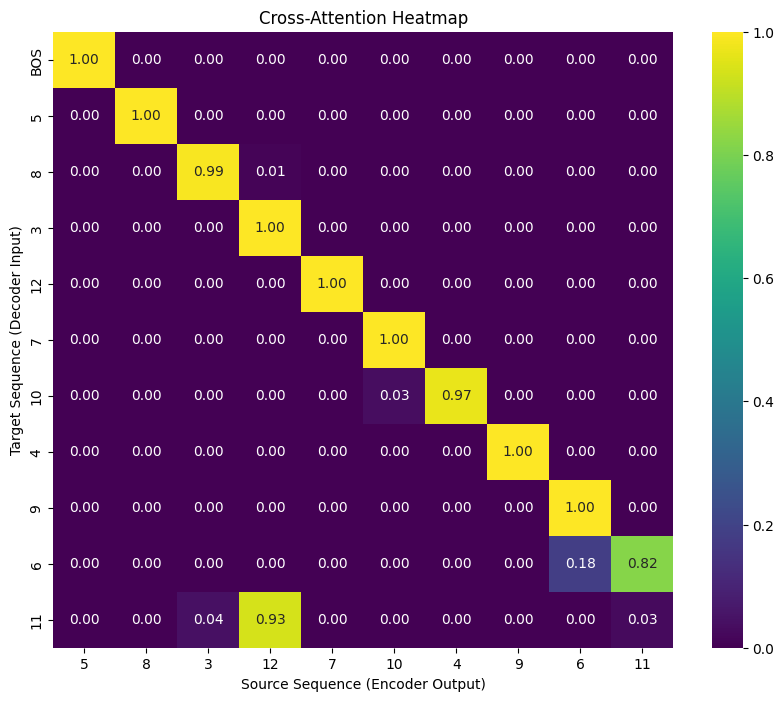

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# Print the attention map for the first head of the first decoder layer
# print(model.decoder[0].cross_attn.attn_map[0,0])

def plot_attention(attention, source_labels, target_labels):
    # Convert tensor to numpy and move to CPU if it's on GPU
    if torch.is_tensor(attention):
        attention = attention.cpu().detach().numpy()

    plt.figure(figsize=(10, 8))

    # Render heatmap using Seaborn
    sns.heatmap(attention,
                xticklabels=source_labels,
                yticklabels=target_labels,
                annot=True,      # Display values in each cell
                fmt=".2f",       # Round to 2 decimal places
                cmap='viridis',  # Color palette (alternatives: 'magma', 'Blues', 'rocket')
                cbar=True)

    plt.xlabel("Source Sequence (Encoder Output)")
    plt.ylabel("Target Sequence (Decoder Input)")
    plt.title("Cross-Attention Heatmap")
    plt.show()

# Example input: test_in = [5, 8, 3, 12, 7, 10, 4, 9, 6, 11]
# Labels for the plot axes
src_labels = [str(x) for x in test_in]
tgt_labels = ["BOS"] + [str(x) for x in test_in] # Decoder receives BOS (Begin Of Sentence) first

# Retrieve the attention matrix from the model (Head 0, Layer 0)
# Expected Shape: [Target_Length, Source_Length]
attn_data = model.decoder[0].cross_attn.attn_map[0, 0]

# Execute the plotting function
plot_attention(attn_data, src_labels, tgt_labels)

# Translation task with Multi30k dataset

## Load dataset from HugingFace

In [14]:
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
import torch
import torch.utils.data as data

dataset = load_dataset("bentrevett/multi30k")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})


## Tokenizer

In [15]:
class BasicTokenizer:
    def __init__(self, sentences, min_freq=2):
        self.special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]
        word_counts = Counter()
        for sentence in sentences:
            word_counts.update(sentence.lower().split())

        self.vocab = {token: i for i, token in enumerate(self.special_tokens)}
        for word, count in word_counts.items():
            if count >= min_freq:
                self.vocab[word] = len(self.vocab)

        self.inv_vocab = {i: token for token, i in self.vocab.items()}
        self.pad_id = self.vocab["<pad>"]
        self.bos_id = self.vocab["<bos>"]
        self.eos_id = self.vocab["<eos>"]
        self.unk_id = self.vocab["<unk>"]

    def encode(self, text):
        return [self.vocab.get(w, self.unk_id) for w in text.lower().split()]

    def decode(self, ids):
        return " ".join([self.inv_vocab.get(i, "<unk>") for i in ids if i not in [0, 1, 2]])

    def __len__(self):
        return len(self.vocab)

def create_masks(src, tgt, pad_idx):
    src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)
    tgt_pad = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
    size = tgt.size(1)
    causal = torch.tril(torch.ones((1, size, size), device=device)).bool()
    return src_mask, tgt_pad & causal

def build_tokenizers(raw_dataset, min_freq=2):
    print("Buiding Tokenizer from train set ...")
    en_tokenizer = BasicTokenizer([x['en'] for x in raw_dataset['train']], min_freq=min_freq)
    de_tokenizer = BasicTokenizer([x['de'] for x in raw_dataset['train']], min_freq=min_freq)
    return en_tokenizer, de_tokenizer

def get_dataloader(data_subset, en_tokenizer, de_tokenizer, batch_size=64, shuffle=False):

    def collate_fn(batch):
        src_list = [torch.tensor(en_tokenizer.encode(x['en'])) for x in batch]
        tgt_list = [torch.tensor([de_tokenizer.bos_id] + de_tokenizer.encode(x['de']) + [de_tokenizer.eos_id]) for x in batch]

        # Padding
        src_pad = pad_sequence(src_list, batch_first=True, padding_value=en_tokenizer.pad_id)
        tgt_pad = pad_sequence(tgt_list, batch_first=True, padding_value=de_tokenizer.pad_id)
        return src_pad, tgt_pad

    return data.DataLoader(
        data_subset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn
    )

en_tok, de_tok = build_tokenizers(dataset)
print(f"English Vocab Size: {len(en_tok)}")
print(f"German Vocab Size: {len(de_tok)}")
train_loader = get_dataloader(dataset['train'], en_tok, de_tok, batch_size=64, shuffle=True)
valid_loader = get_dataloader(dataset['validation'], en_tok, de_tok, batch_size=64, shuffle=False)
test_loader  = get_dataloader(dataset['test'], en_tok, de_tok, batch_size=64, shuffle=False)

Buiding Tokenizer from train set ...
English Vocab Size: 7704
German Vocab Size: 9597


## Model architecture

In [16]:
class TranslateTransformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=256, heads=8, layers=3, d_ff=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab, d_model)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model)
        self.pe = PositionalEncoding(d_model, dropout)

        self.encoder = nn.ModuleList([EncoderLayer(d_model, heads, d_ff, dropout) for _ in range(layers)])
        self.decoder = nn.ModuleList([DecoderLayer(d_model, heads, d_ff, dropout) for _ in range(layers)])
        self.fc_out = nn.Linear(d_model, tgt_vocab)

        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, s_mask, t_mask):
        mem = self.pe(self.src_emb(src) * math.sqrt(self.d_model))
        for layer in self.encoder: mem = layer(mem, s_mask)

        out = self.pe(self.tgt_emb(tgt) * math.sqrt(self.d_model))
        for layer in self.decoder: out = layer(out, mem, s_mask, t_mask)
        return F.log_softmax(self.fc_out(out), dim=-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TranslateTransformer(
    src_vocab=len(en_tok),
    tgt_vocab=len(de_tok),
    d_model=256,
    layers=3
).to(device)

print(model)

def count_parameters(model):
    # Trainable
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'-'*30}")
    print(f"Model Name: {model.__class__.__name__}")
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"{'-'*30}\n")

count_parameters(model)

TranslateTransformer(
  (src_emb): Embedding(7704, 256)
  (tgt_emb): Embedding(9597, 256)
  (pe): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): ModuleList(
    (0-2): 3 x EncoderLayer(
      (self_attn): MultiHeadAttention(
        (linears): ModuleList(
          (0-3): 4 x Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (w_1): Linear(in_features=256, out_features=512, bias=True)
        (w_2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (decoder): ModuleList(
    (0-2): 3 x DecoderLayer(
      (self_attn): MultiHeadAttention(
        (linears): ModuleList(
          (0-3): 4 x Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout): Dropout(p=0.

## Training loop

In [17]:
from tqdm.notebook import tqdm

def train_epoch(model, loader, optimizer, scheduler, criterion, device, target_vocab_size, pad_idx):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]

        src_mask, tgt_mask = create_masks(src, tgt_in, pad_idx)

        preds = model(src, tgt_in, src_mask, tgt_mask)
        loss = criterion(preds.reshape(-1, target_vocab_size), tgt_out.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scheduler.step()

        total_loss += loss.item()

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
scheduler = NoamScheduler(optimizer, d_model=256, warmup=1000)
criterion = nn.NLLLoss(ignore_index=de_tok.pad_id)
epochs = 30
pbar_main = tqdm(range(epochs), desc="Total Progress")

for epoch in pbar_main:
    train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, criterion,
        device, len(de_tok), de_tok.pad_id
    )

    pbar_main.set_description(f"Epoch {epoch+1}/{epochs}")
    pbar_main.set_postfix(avg_loss=f"{train_loss:.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

print("\nAll epochs completed!")

## Evaluate BLEU

In [19]:
def batch_predict(model, src_tensor, en_tok, de_tok, device, max_len=50):
    model.eval()
    batch_size = src_tensor.size(0)

    # 1. Encoder Pass
    # Create source mask to ignore padding tokens
    src_mask = (src_tensor != en_tok.pad_id).unsqueeze(1).unsqueeze(2)
    # Apply embedding and positional encoding to source input
    memory = model.pe(model.src_emb(src_tensor) * math.sqrt(model.d_model))
    for layer in model.encoder:
        memory = layer(memory, src_mask)

    # 2. Initialize sequences with the <bos> (Begin Of Sentence) token
    res_ids = torch.full((batch_size, 1), de_tok.bos_id, dtype=torch.long, device=device)

    # Boolean mask to track sequences that have reached the <eos> (End Of Sentence) token
    finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

    # Greedy decoding loop
    for _ in range(max_len):
        # Generate target masks: combine padding mask and causal (look-ahead) mask
        tgt_pad_mask = (res_ids != de_tok.pad_id).unsqueeze(1).unsqueeze(2)
        size = res_ids.size(1)
        causal_mask = torch.tril(torch.ones((1, size, size), device=device)).bool()
        tgt_mask = tgt_pad_mask & causal_mask

        # Decoder Pass
        out = model.pe(model.tgt_emb(res_ids) * math.sqrt(model.d_model))
        for layer in model.decoder:
            out = layer(out, memory, src_mask, tgt_mask)

        # Get logits for the last token and find the word with the highest probability
        prob = model.fc_out(out[:, -1])
        next_words = torch.argmax(prob, dim=-1) # shape: (batch_size)

        # Append the predicted words to the current result sequences
        res_ids = torch.cat([res_ids, next_words.unsqueeze(1)], dim=1)

        # Update the finished status for sequences that just generated <eos>
        finished |= (next_words == de_tok.eos_id)

        # Early exit if all sequences in the batch have reached <eos>
        if finished.all():
            break

    return res_ids

In [20]:
from nltk.translate.bleu_score import corpus_bleu

def calculate_bleu(model, loader, en_tok, de_tok, device):
    model.eval()
    targets = []
    predictions = []

    print("Evaluating BLEU score ...")

    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device)

            # 1. Batch Decoding
            # Output shape: (batch_size, max_generated_seq_len)
            generated_ids = batch_predict(model, src, en_tok, de_tok, device)

            # 2. Convert IDs back to tokens and format for BLEU calculation
            for i in range(src.size(0)):
                # Process Ground Truth (Reference translation)
                # Filter out special tokens: <pad>, <bos>, <eos>
                ref_ids = tgt[i].tolist()
                ref_tokens = [de_tok.inv_vocab[idx] for idx in ref_ids
                              if idx not in [de_tok.pad_id, de_tok.bos_id, de_tok.eos_id]]

                # Process Model Prediction (Candidate translation)
                pred_ids = generated_ids[i].tolist()
                pred_tokens = [de_tok.inv_vocab[idx] for idx in pred_ids
                               if idx not in [de_tok.pad_id, de_tok.bos_id, de_tok.eos_id]]

                # corpus_bleu expects a list of lists of tokens for references
                targets.append([ref_tokens])
                predictions.append(pred_tokens)

    # Calculate BLEU score (standard 1-to-4-gram cumulative score)
    bleu_score = corpus_bleu(targets, predictions)
    return bleu_score * 100

In [21]:
valid_bleu = calculate_bleu(model, valid_loader, en_tok, de_tok, device)
test_bleu = calculate_bleu(model, test_loader, en_tok, de_tok, device)
print(f"\nBLEU Score on Validation Set: {valid_bleu:.2f}")
print(f"\nBLEU Score on Test Set: {test_bleu:.2f}")

Evaluating BLEU score ...
Evaluating BLEU score ...

BLEU Score on Validation Set: 25.01

BLEU Score on Test Set: 25.15
